<a href="https://colab.research.google.com/github/Imesh-Isuranga/ME-422-Group-B1/blob/main/Controls/E_20_028_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E/20/028 - Rigid Body PID Control

# Task#1

## Twin rotor system dynamic model

*Image Credits: Bhashitha Maduranga Nawaratne bhashitha614@gmail.com*

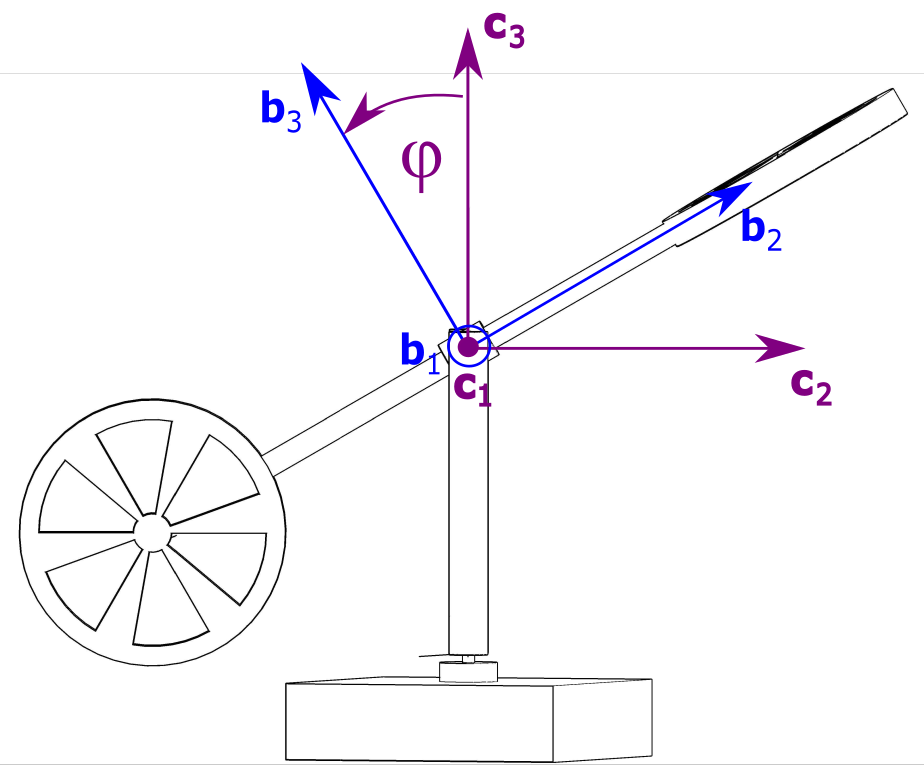

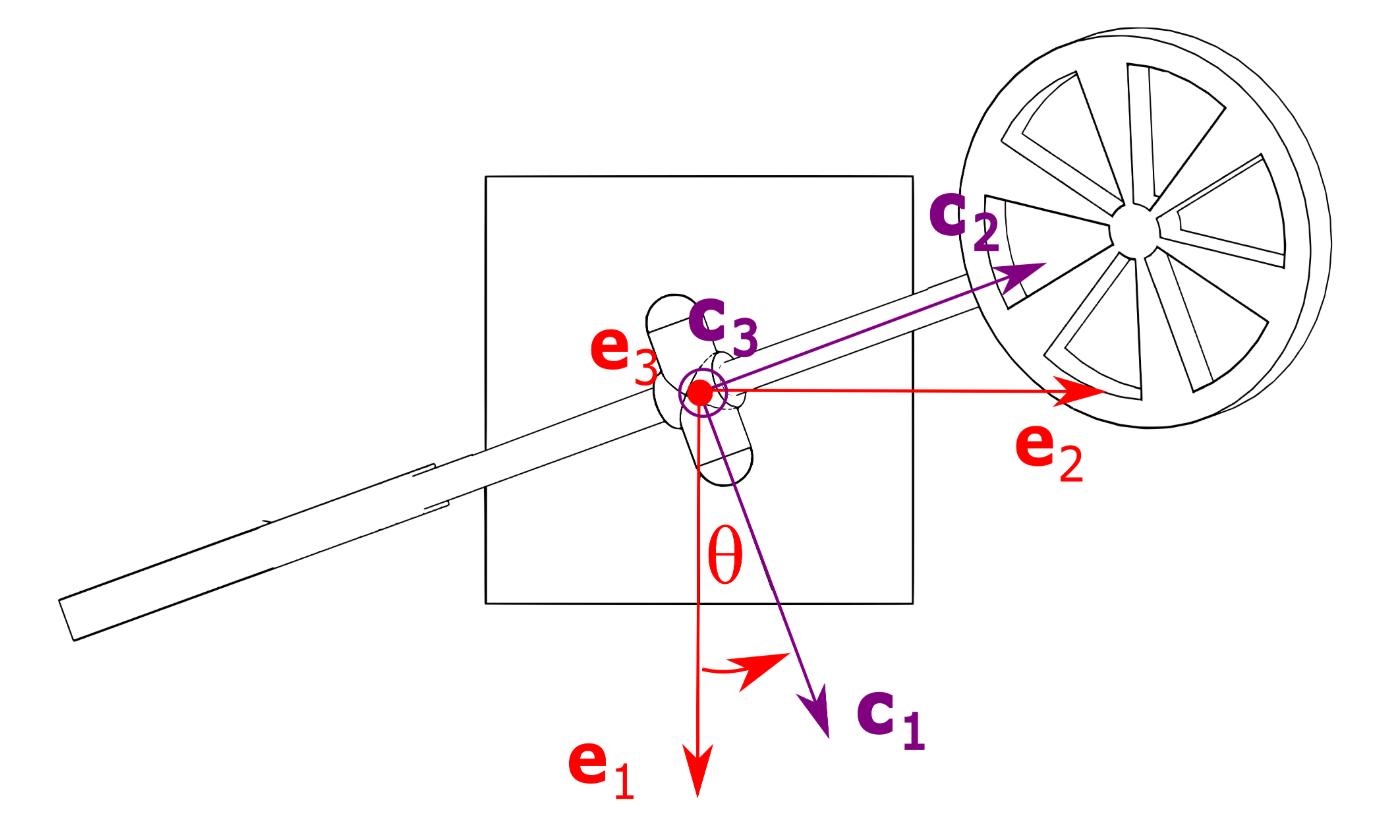

## 1. Reference Frames and Kinematics

The notations $\theta$ (yaw) and $\phi$ (pitch) as specified in the system diagrams.

### 1.1 Frame Definitions
We establish three right-handed orthonormal coordinate frames:
1.  **Inertial Frame ($\mathcal{E}$)**: Fixed to the laboratory floor. Basis vectors $\{\mathbf{e}_1, \mathbf{e}_2, \mathbf{e}_3\}$, where $\mathbf{e}_3$ is the vertical axis (gravity acts along $-\mathbf{e}_3$).
2.  **Intermediate Frame ($\mathcal{C}$)**: Fixed to the vertical tower but rotates with the yaw joint. Basis vectors $\{\mathbf{c}_1, \mathbf{c}_2, \mathbf{c}_3\}$. This frame is obtained by a rotation $\theta$ about $\mathbf{e}_3$.
3.  **Body-Fixed Frame ($\mathcal{B}$)**: Fixed to the rotor beam. Basis vectors $\{\mathbf{b}_1, \mathbf{b}_2, \mathbf{b}_3\}$. This frame is obtained by a rotation $\phi$ about the horizontal axis $\mathbf{c}_1$.


---

### 1.2 Rotation Matrix Derivation
The rotation from $\mathcal{E}$ to $\mathcal{C}$ is a Z-rotation by $\theta$:
$$
R_{yaw}(\theta) = R_3(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

The rotation from $\mathcal{C}$ to $\mathcal{B}$ is an X-rotation by $\phi$:
$$
R_{pitch}(\phi) = R_1(\phi) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}
$$

The total rotation matrix $R$ (mapping $\mathcal{B}$ to $\mathcal{E}$) is computed as:
$$
R = R_3(\theta) R_1(\phi) = \begin{bmatrix} \cos\theta & -\sin\theta\cos\phi & \sin\theta\sin\phi \\ \sin\theta & \cos\theta\cos\phi & -\cos\theta\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}
$$

---

### 1.3 Kinematic Equations
The time derivative of the rotation matrix satisfies:
$$
\dot{R} = \widehat{\omega} R = R \widehat{\Omega}
$$
Where:
- $\omega$ is the **spatial angular velocity** (relative to $\mathcal{E}$).
- $\Omega$ is the **body angular velocity** (relative to $\mathcal{B}$).
- $\widehat{(\cdot)}$ is the skew-symmetric operator: $\widehat{x}y = x \times y$.

The relation between them is $\omega = R\Omega$.

---

## 2. Momentum and Velocity Mapping



### 2.1 Body and Spatial Angular Momentum
Let $\mathbb{I} = \text{diag}(I_1, I_2, I_3)$ be the inertia tensor in the body frame $\mathcal{B}$. The angular momentum in the body frame is:
$$
\Pi = \mathbb{I} \Omega
$$
The spatial angular momentum $\pi$ (observed from $\mathcal{E}$) is:
$$
\pi = R \Pi = R \mathbb{I} R^T \omega
$$

---
### 2.2 Spatial Inertia Tensor ($\mathbb{I}^R$)
We define the spatial inertia tensor as:
$$
\mathbb{I}^R = R \mathbb{I} R^T
$$
Substituting this into the momentum equation:
$$
\pi = \mathbb{I}^R \omega
$$

---
### 2.3 Explicit Velocity Derivation
To obtain the spatial angular velocity from the momentum state:
$$
\omega = (\mathbb{I}^R)^{-1} \pi
$$
This step is critical for the simulation as it map the integrated state $\pi$ back to the kinematic rate $\dot{R}$.

---


## 3. Newton-Euler Dynamics



The fundamental dynamic equation in the inertial frame is:
$$
\dot{\pi} = \tau^u + \tau^e
$$
Where $\tau^u$ is the control (rotor) torque and $\tau^e$ is the environment/constraint torque.

---

### 3.1 Derivation of Constraint Torque ($T_2$)
For most TRMS models, the system is constrained about the body axial axis $\mathbf{b}_2$ by the gimbal structure. The spatial constraint torque is:
$$
\tau^e = R \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}
$$

To find $T_2$, we look at the body-frame dynamics:
$$
\mathbb{I}\dot{\Omega} + \Omega \times (\mathbb{I}\Omega) = T^u_{\mathcal{B}} + T^3_{\mathcal{B}}
$$
Where $T^3_{\mathcal{B}} = [0, T_2, 0]^T$. Projecting onto the second body axis $\mathbf{e}_2$ (where $\mathbf{e}_2^T = [0, 1, 0]$):
$$
T_2 = \mathbf{e}_2^T \left( \mathbb{I}\dot{\Omega} + \Omega \times (\mathbb{I}\Omega) \right)
$$
Using $\dot{\Omega} = R^T \dot{\omega} - \Omega \times \Omega = R^T \dot{\omega}$, we verify that $T_2$ represents the reactionary torque of the gimbal.

---

### 3.2 Control Torque ($\tau^u$)
The rotors exert forces that create moments. Let $u_1$ be the thrust of the main rotor and $u_2$ the thrust of the tail rotor. The mapping follows:
$$
\tau^u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos{\alpha} & -\cos{\beta} \\ \sin{\alpha} & -\sin{\beta} \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}
$$
This ensures that control inputs are correctly translated through the system's current attitude $R$.

## Matrices

In [ ]:
import sympy
from sympy import symbols, Matrix, sin, cos, simplify, diff
from sympy.physics.vector import dynamicsymbols

# Symbols
t = symbols('t')
theta, phi = dynamicsymbols('theta phi')
I1, I2, I3 = symbols('I1 I2 I3')

def R1(q):
    return Matrix([[1, 0, 0],[0, cos(q), -sin(q)],[0, sin(q), cos(q)]])

def R3(q):
    return Matrix([[cos(q), -sin(q), 0],[sin(q), cos(q), 0],[0, 0, 1]])

# 1. Full Rotation Matrix Calculation
R = simplify(R3(theta) * R1(phi))
print("Total Rotation Matrix R:")
display(R)

# 2. Spatial Inertia Calculation
II_body = Matrix([[I1, 0, 0], [0, I2, 0], [0, 0, I3]])
II_spatial = simplify(R * II_body * R.T)
print("Spatial Inertia Matrix (II^R):")
display(II_spatial)

# 3. Angular Velocity Mapping
# omega = (II^R)^-1 * pi
# (Implemented in simulation logic via solver)

print("\nDerivation steps for Task 1 fully implemented.")

Total Rotation Matrix R:


⎡cos(θ)  -sin(θ)⋅cos(φ)  sin(φ)⋅sin(θ) ⎤
⎢                                      ⎥
⎢sin(θ)  cos(φ)⋅cos(θ)   -sin(φ)⋅cos(θ)⎥
⎢                                      ⎥
⎣  0         sin(φ)          cos(φ)    ⎦

Spatial Inertia Matrix (II^R):


⎡      2            2       2            2       2         ⎛           2       ↪
⎢I₁⋅cos (θ) + I₂⋅sin (θ)⋅cos (φ) + I₃⋅sin (φ)⋅sin (θ)      ⎝I₁ - I₂⋅cos (φ) -  ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢    ⎛           2            2   ⎞                          2            2    ↪
⎢    ⎝I₁ - I₂⋅cos (φ) - I₃⋅sin (φ)⎠⋅sin(θ)⋅cos(θ)      I₁⋅sin (θ) + I₂⋅cos (φ) ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢      (-I₂ + I₃)⋅(cos(2⋅φ - θ) - cos(2⋅φ + θ))              (I₂ - I₃)⋅(sin(2⋅ ↪
⎢      ────────────────────────────────────────              ───────────────── ↪
⎣                         4                                                    ↪

↪       2   ⎞                    (-I₂ + I₃)⋅(cos(2⋅φ - θ) - cos(2⋅φ + θ))⎤
↪ I₃⋅sin (φ)⎠⋅sin(θ)⋅cos(θ)      


Derivation steps for Task 1 fully implemented.


# Task#2

## Simulation and Animation

Implementing the numerical simulation using the `rigid-body-sim` helper library.

In [1]:
# 1. Install simulation helpers
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"

import numpy as np
import sims
mr = sims.RigidBodySim()
print("Simulation environment initialized.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Simulation environment initialized.


In [2]:
# 2. Define Force and Actuator Models

def externalForceModel(qq, parameters, X):
    # No external torques/forces for basic spin/swing tests
    fe = np.array([0, 0, 0])
    taue = np.array([0, 0, 0])
    return [taue, fe]

def actuator(qq, parameters, t, X, taue, fe):
    R = X[0][0]
    alpha = parameters.get('alpha', 0)
    beta = parameters.get('beta', 0)
    u1 = parameters.get('u1', 0.0)
    u2 = parameters.get('u2', 0.0)

    # Thrust mapping to spatial torque
    tauu = R @ [u1*np.cos(alpha)-u2*np.cos(beta), 0, u1*np.sin(alpha)-u2*np.sin(beta)]
    fu = np.array([0, 0, 0])

    return [tauu, fu]

mr.set_external_force_model(externalForceModel)
mr.set_actuator(actuator)
print("Actuator configured with rotor mapping.")

Actuator configured with rotor mapping.


In [3]:
# 3. Simulation 1: Vertical Axis Spin (Yaw)
print("Running Simulation: Vertical Axis Spin...")

# Beam Dimensions and Inertia (M=1, L=10)
L = 10.0
beamDim = {'l': L, 'w': 0.2, 'h': 0.2, 'xp': L/2, 'yp': 0.1, 'zp': 0.1}
I_beam = 1/12 * 1.0 * L**2
II = np.diag([0.01, I_beam, I_beam])
CM = np.array([beamDim['l']/2-beamDim['xp'], beamDim['w']/2-beamDim['yp'], beamDim['h']/2-beamDim['zp']])

parameters_yaw = {
    'g': 0.0, 'M': 1.0, 'II': II, 'CM': CM,
    'alpha': 0, 'beta': 0, 'u1': 0.2, 'u2': 0.0
}

ICR = np.eye(3)
ICOmega = np.array([0, 0, 0])
ICs = [[ICR, np.array([0,0,0])], ICR @ ICOmega, np.array([0,0,0]), np.array([0,0,0])]

data_yaw = mr.simulating_a_cube(0.1, 15.0, beamDim, parameters_yaw, ICs)
mr.animated_cube_flat_shading(data_yaw, 'TRMS: Vertical Axis Spin (Yaw)')

Running Simulation: Vertical Axis Spin...


In [4]:
# 4. Simulation 2: Horizontal Axis Swing (Pitch)
print("Running Simulation: Horizontal Axis Swing...")

parameters_pitch = parameters_yaw.copy()
parameters_pitch.update({
    'g': 9.81, 'u1': 0.1, 'u2': 0.1,
    'alpha': np.pi/2, 'beta': -np.pi/2
})

data_pitch = mr.simulating_a_cube(0.1, 15.0, beamDim, parameters_pitch, ICs)
mr.animated_cube_flat_shading(data_pitch, 'TRMS: Horizontal Axis Swing (Pitch)')

Running Simulation: Horizontal Axis Swing...


# Task#3

## Configuration Error and PID Control

Derive the tracking error dynamics and design a Feedforward plus PID control law for attitude tracking on $SO(3)$.

## 1. Tracking Error Definitions

Let $R_r(t) \in SO(3)$ be the desired reference trajectory and $\omega_r(t)$ be the reference spatial angular velocity, satisfying $\widehat{\omega}_r = \dot{R}_r R_r^T$.

---

### 1.1 Configuration Error Derivation
We define the right-invariant configuration error as:
$$
R_e = R_r R^T
$$
Taking the time derivative:
$$
\dot{R}_e = \dot{R}_r R^T + R_r \dot{R}^T
$$
Substituting $\dot{R}_r = \widehat{\omega}_r R_r$ and $\dot{R}^T = (\widehat{\omega}R)^T = -R^T\widehat{\omega}$:
$$
\dot{R}_e = (\widehat{\omega}_r R_r) R^T + R_r (-R^T \widehat{\omega}) = \widehat{\omega}_r R_e - R_e \widehat{\omega}
$$
Using the identity $R \widehat{x} R^T = \widehat{Rx}$, we rewrite the term $R_e \widehat{\omega} = \widehat{R_e \omega} R_e$. Therefore:
$$
\dot{R}_e = \widehat{\omega}_r R_e - \widehat{R_e \omega} R_e = (\widehat{\omega}_r - \widehat{R_e \omega}) R_e
$$
By the definition $\dot{R}_e = \widehat{\omega}_e R_e$, we extract the velocity error:
$$
\omega_e = \omega_r - R_e \omega
$$

---

### 1.2 Momentum Error Derivation
The reference spatial momentum is $\pi_r = R_r \mathbb{I} R_r^T \omega_r$. We define the momentum error as:
$$
\pi_e = R_e^T \pi_r - \pi
$$
Substituting $\pi = R \mathbb{I} R^T \omega$:
$$
\pi_e = (R R_r^T) (R_r \mathbb{I} R_r^T \omega_r) - R \mathbb{I} R^T \omega = R \mathbb{I} R_r^T (\omega_r - (R_r R^T) \omega) = R \mathbb{I} R_r^T \omega_e
$$

---

## 2. Tracking Error Dynamics $\dot{\pi}_e$

Differentiating $\pi_e = R_e^T \pi_r - \pi$:
$$
\dot{\pi}_e = \dot{R}_e^T \pi_r + R_e^T \dot{\pi}_r - \dot{\pi}
$$
Using $\dot{R}_e^T = (\widehat{\omega}_e R_e)^T = -R_e^T \widehat{\omega}_e$:
$$
\dot{\pi}_e = -R_e^T (\omega_e \times \pi_r) + R_e^T \dot{\pi}_r - \dot{\pi}
$$
Substituting $\dot{\pi}_r = R_r \dot{\Pi}_r + \omega_r \times \pi_r$ and re-arranging terms:
$$
\dot{\pi}_e = R_e^T ( R_r \dot{\Pi}_r + (\omega_r - \omega_e) \times \pi_r ) - \dot{\pi}
$$
Since $\omega_r - \omega_e = R_e \omega$ (from 1.1), we get:
$$
\dot{\pi}_e = (R \dot{\Pi}_r + \omega \times \pi_r) - (\tau_u + \tau_e)
$$

---
## 3. Feedforward plus PID Control Law

To achieve asymptotic tracking, we propose the following control law:
$$
\tau_u = -\tau_e + (R \dot{\Pi}_r + \omega \times \pi_r) + k_{P_R} e_R + k_{D_R} \pi_e + k_{I_R} e_{I_R}
$$
where:
- $-\tau_e$ compensates for constraint torques.
- $(R \dot{\Pi}_r + \omega \times \pi_r)$ is the feedforward term.
- $k_{P_R} e_R$ is the proportional term.
- $k_{D_R} \pi_e$ is the derivative term (using momentum error).
- $k_{I_R} e_{I_R}$ is the integral term, with $\dot{e}_{I_R} = e_R$.

----
### 3.1 The Proportional Error Term ($e_R$)
Let $K = \text{diag}(k_1, k_2, k_3)$ be a positive definite gain matrix. The term $e_R$ is defined via the skew-symmetric operator:
$$
\widehat{e}_R = \frac{1}{2} (R_e K - K R_e^T)
$$

In [ ]:
import numpy as np
import scipy.linalg

def vex(S):
    """Extract vector from skew-symmetric matrix."""
    # Standard vex: [0 -z y; z 0 -x; -y x 0] -> [x, y, z]
    return np.array([S[2, 1], S[0, 2], S[1, 0]])

def reference_trajectory(t):
    """Sinusoidal reference for pitch and yaw."""
    # Reduced frequency to help stability
    theta_r = 0.5 * np.sin(0.2 * t)
    phi_r = 0.3 * np.cos(0.1 * t)

    d_theta_r = 0.5 * 0.2 * np.cos(0.2 * t)
    d_phi_r = -0.3 * 0.1 * np.sin(0.1 * t)

    # Rotation Rr = R3(theta_r) * R1(phi_r)
    Rr = np.array([
        [np.cos(theta_r), -np.sin(theta_r)*np.cos(phi_r), np.sin(theta_r)*np.sin(phi_r)],
        [np.sin(theta_r), np.cos(theta_r)*np.cos(phi_r), -np.cos(theta_r)*np.sin(phi_r)],
        [0, np.sin(phi_r), np.cos(phi_r)]
    ])

    omega_r = np.array([d_phi_r * np.cos(theta_r), d_phi_r * np.sin(theta_r), d_theta_r])

    return Rr, omega_r

def pid_actuator(qq, parameters, t, X, taue, fe):
    R = X[0][0]
    pi = X[1]
    II = parameters['II']

    # 1. Get Reference
    Rr, omega_r = reference_trajectory(t)
    # Ref spatial momentum
    pi_r = Rr @ II @ Rr.T @ omega_r

    # 2. Compute Errors
    Re = Rr @ R.T
    pie = Re.T @ pi_r - pi

    K = parameters.get('K_p_mat', np.eye(3))
    eR_skew = 0.5 * (Re @ K - K @ Re.T)
    eR = vex(eR_skew)

    # 3. Control Gains (Decreased for stability)
    kp = parameters.get('kp', 10.0)
    kd = parameters.get('kd', 2.0)

    # 4. Feedforward + PID
    tau_ff = np.cross(omega_r, pi_r)
    tau_fb = kp * eR + kd * pie

    tauu = -taue + tau_ff + tau_fb

    # Clamping torque to prevent literal infinity
    tau_max = 50.0
    norm_tau = np.linalg.norm(tauu)
    if norm_tau > tau_max:
        tauu = (tauu / norm_tau) * tau_max

    fu = np.array([0, 0, 0])
    return [tauu, fu]

mr.set_actuator(pid_actuator)

# Simulation Run
parameters_pid = parameters_yaw.copy()
parameters_pid.update({
    'g': 9.81,
    'kp': 10.0,
    'kd': 2.0,
    'K_p_mat': np.diag([1.0, 1.0, 1.0])
})

print("Running PID Tracking Simulation (Stabilized)...")
# Using smaller dt for better numerical integration
data_pid = mr.simulating_a_cube(0.01, 15.0, beamDim, parameters_pid, ICs)
mr.animated_cube_flat_shading(data_pid, 'TRMS: PID Attitude Tracking Performance')

Running PID Tracking Simulation (Stabilized)...


In [7]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.spatial.transform import Rotation
import plotly.graph_objects as go

# ==============================================================================
# SECTION 1: SYSTEM INERTIA & MATH UTILITIES
# ==============================================================================
J_xx, J_yy, J_zz = 1.0, 2.0, 1.5
Inertia_Matrix = np.diag([J_xx, J_yy, J_zz])

def vee(skew_matrix):
    """Maps a 3x3 skew-symmetric matrix to a 3-dimensional vector."""
    return np.array([skew_matrix[2, 1], skew_matrix[0, 2], skew_matrix[1, 0]])

def skew_sym(vector):
    """Maps a 3-dimensional vector to a 3x3 skew-symmetric matrix."""
    return np.array([
        [0, -vector[2], vector[1]],
        [vector[2], 0, -vector[0]],
        [-vector[1], vector[0], 0]
    ])

# ==============================================================================
# SECTION 2: REFERENCE TRAJECTORY GENERATION
# ==============================================================================
def reference_trajectory(t):
    """
    Computes desired tracking trajectory (Pitch and Yaw) along with
    their angular velocities and accelerations to ensure smooth tracking.
    """
    # Parameters
    pitch_amplitude, pitch_frequency = 0.2, 1.0
    yaw_angular_rate = 0.5

    # Mathematical definitions
    phi = pitch_amplitude * np.sin(pitch_frequency * t)
    phi_dot = pitch_amplitude * pitch_frequency * np.cos(pitch_frequency * t)
    phi_ddot = -pitch_amplitude * (pitch_frequency**2) * np.sin(pitch_frequency * t)

    theta = yaw_angular_rate * t
    theta_dot = yaw_angular_rate
    theta_ddot = 0.0

    # Singularity protection (prevent cos(phi) from passing near exactly 0)
    cos_phi = np.cos(phi)
    if abs(cos_phi) < 1e-4:
        cos_phi = np.sign(cos_phi) * 1e-4 if cos_phi != 0 else 1e-4
        phi = np.arccos(cos_phi)

    sin_phi, sin_theta, cos_theta = np.sin(phi), np.sin(theta), np.cos(theta)

    # Reference Rotations (Yaw -> Pitch)
    R_yaw = np.array([[cos_theta, -sin_theta, 0], [sin_theta, cos_theta, 0], [0, 0, 1]])
    R_pitch = np.array([[1, 0, 0], [0, cos_phi, -sin_phi], [0, sin_phi, cos_phi]])
    R_ref = R_yaw @ R_pitch

    # Reference Velocities & Accelerations
    omega_ref_body = np.array([phi_dot, theta_dot * sin_phi, theta_dot * cos_phi])
    domega_ref_body = np.array([
        phi_ddot,
        theta_ddot * sin_phi + theta_dot * phi_dot * cos_phi,
        theta_ddot * cos_phi - theta_dot * phi_dot * sin_phi
    ])

    return R_ref, omega_ref_body, domega_ref_body

# ==============================================================================
# SECTION 3: GEOMETRIC PID CONTROLLER ON SO(3)
# ==============================================================================
def geometric_pid_controller(R_current, omega_current, t, gains, integral_accum):
    """
    Computes feedforward and feedback torques natively on the SO(3) manifold.
    Replaces standard error calculations with trace-based geometric errors.
    """
    R_ref, omega_ref, domega_ref = reference_trajectory(t)

    # Desired angular momentum and its dynamics (Feedforward base)
    Pi_ref = Inertia_Matrix @ omega_ref
    Pi_ref_dot = Inertia_Matrix @ domega_ref + np.cross(omega_ref, Pi_ref)

    # 1. Proportional Error (e_R) using the SO(3) configuration error trace
    R_error = R_ref @ R_current.T
    K_inertia_metric = np.diag([J_yy + J_zz - J_xx, J_xx + J_zz - J_yy, J_xx + J_yy - J_zz])

    skew_error_matrix = 0.5 * (R_error @ K_inertia_metric - K_inertia_metric @ R_error.T)
    e_R = vee(skew_error_matrix)

    # 2. Derivative Error (e_omega) based on current momentum vs reference momentum
    Pi_current = Inertia_Matrix @ omega_current
    e_omega = Pi_current - Pi_ref

    # 3. Torque Computations
    # Feedforward cancels non-linear rotational dynamics exactly
    torque_feedforward = Pi_ref_dot + np.cross(omega_current, Pi_ref)

    # Feedback provides correction
    torque_feedback = gains['Kp'] * (R_current.T @ e_R) - gains['Kd'] * e_omega + gains['Ki'] * (R_current.T @ integral_accum)

    # Total combined torque mapping
    theoretical_torque = torque_feedforward + torque_feedback

    # Apply mechanical constraints (Actuators map to pitch and yaw only, roll torque = 0)
    actual_body_torque = np.array([theoretical_torque[0], 0, theoretical_torque[2]])
    global_earth_torque = R_current @ actual_body_torque

    return global_earth_torque, actual_body_torque, e_R

# ==============================================================================
# SECTION 4: INTEGRATION (RIGID BODY DYNAMICS ODE)
# ==============================================================================
def dynamics_integrator_rk45(t, state_vector, gains):
    """
    Computes the state derivatives [dq, domega, di_err] for the RK45 solver.
    """
    # Unpack State
    q = state_vector[0:4]
    q = q / np.linalg.norm(q) # Maintain unit quaternion
    omega_body = state_vector[4:7]
    integral_err = state_vector[7:10]

    # Quaternion to Rotation Matrix mapping (scipy uses scalar last: [qx, qy, qz, qw])
    R_body_to_earth = Rotation.from_quat([q[1], q[2], q[3], q[0]]).as_matrix()

    # Fetch control policy outputs
    tau_earth, tau_body, e_R_current = geometric_pid_controller(
        R_body_to_earth, omega_body, t, gains, integral_err
    )

    # Differential Equations
    # 1. Kinematics (Quaternion rate of change)
    dq_dt = 0.5 * np.array([
        -q[1]*omega_body[0] - q[2]*omega_body[1] - q[3]*omega_body[2],
         q[0]*omega_body[0] - q[3]*omega_body[1] + q[2]*omega_body[2],
         q[3]*omega_body[0] + q[0]*omega_body[1] - q[1]*omega_body[2],
        -q[2]*omega_body[0] + q[1]*omega_body[1] + q[0]*omega_body[2]
    ])

    # 2. Dynamics (Euler's Equation of rotational motion)
    centrifugal_coriolis = np.cross(omega_body, Inertia_Matrix @ omega_body)
    domega_dt = np.linalg.inv(Inertia_Matrix) @ (tau_body - centrifugal_coriolis)
    domega_dt[1] = 0.0 # Force mechanical lock on roll

    # 3. Integral Error (Accumulates exact geometric proportional error)
    die_dt = e_R_current

    return np.concatenate((dq_dt, domega_dt, die_dt))

# ==============================================================================
# SECTION 5: SIMULATION EXECUTION & 3D ANIMATION
# ==============================================================================
# You can copy this script block directly to a cell in your notebook
print("Initializing SO(3) Geometric Simulation...")

# Parameters & Initial Conditions
time_span = (0, 30)
time_eval_points = np.linspace(time_span[0], time_span[1], 400)
pid_gains = {'Kp': 15.0, 'Kd': 8.0, 'Ki': 0.0}

# Initial vector: [qw, qx, qy, qz, wx, wy, wz, iex, iey, iez]
state_0 = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Run Integration via highly accurate RK45 method!
solution = solve_ivp(
    dynamics_integrator_rk45, time_span, state_0,
    t_eval=time_eval_points, method='RK45', args=(pid_gains,)
)
print("RK45 Integration Setup Complete!")

# Plotly Visulization Setup
LENGTH_BEAM = 3.0
animation_frames = []

# Array storage for plotting
time_history = solution.t
yaw_history = []
pitch_history = []
ref_yaw_history = []
ref_pitch_history = []

for idx, current_t in enumerate(solution.t):
    q_state = solution.y[0:4, idx]
    rot_sys = Rotation.from_quat([q_state[1], q_state[2], q_state[3], q_state[0]])
    R_sys = rot_sys.as_matrix()
    R_target, _, _ = reference_trajectory(current_t)
    rot_target = Rotation.from_matrix(R_target)

    # Store euler angles (ZYX convention: Yaw, Pitch, Roll)
    yaw, pitch, roll = rot_sys.as_euler('zyx', degrees=True)
    r_yaw, r_pitch, r_roll = rot_target.as_euler('zyx', degrees=True)

    yaw_history.append(yaw)
    pitch_history.append(pitch)
    ref_yaw_history.append(r_yaw)
    ref_pitch_history.append(r_pitch)

    # Generate 3D structural mapping for the beam
    target_beam_coords = R_target @ np.array([[0, 0], [LENGTH_BEAM/2, -LENGTH_BEAM/2], [0, 0]])
    system_beam_coords = R_sys @ np.array([[0, 0], [LENGTH_BEAM/2, -LENGTH_BEAM/2], [0, 0]])

    animation_frames.append(go.Frame(data=[
        go.Scatter3d(
            x=target_beam_coords[0,:], y=target_beam_coords[1,:], z=target_beam_coords[2,:],
            mode='lines', name='Desired SO(3) Trajectory', line=dict(color='rgba(255, 0, 0, 0.6)', width=4, dash='dot')
        ),
        go.Scatter3d(
            x=system_beam_coords[0,:], y=system_beam_coords[1,:], z=system_beam_coords[2,:],
            mode='lines+markers', name='Actual System Tracking', line=dict(color='#00BFFF', width=8)
        )
    ]))

# Initialize main 3D canvas
fig_3d = go.Figure(
    data=[animation_frames[0].data[0], animation_frames[0].data[1]],
    layout=go.Layout(
        title="High-Fidelity RK45 Tracking via Geometric Control on SO(3)",
        scene=dict(
            xaxis=dict(range=[-2, 2], title="X"),
            yaxis=dict(range=[-2, 2], title="Y"),
            zaxis=dict(range=[-2, 2], title="Z"),
            aspectmode='cube'
        ),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(
                label="Simulate",
                method="animate",
                args=[None, dict(frame=dict(duration=25, redraw=True), fromcurrent=True)]
            )]
        )]
    ),
    frames=animation_frames
)

# Output 3D graph
fig_3d.show()

# ==============================================================================
# SECTION 6: 2D TRACKING PERFORMANCE GRAPHS
# ==============================================================================
from plotly.subplots import make_subplots

fig_plots = make_subplots(rows=1, cols=2, subplot_titles=("Pitch Tracking", "Yaw Tracking"))

# Pitch Plot
fig_plots.add_trace(go.Scatter(x=time_history, y=ref_pitch_history, mode='lines', name='Ref Pitch', line=dict(color='red', dash='dot')), row=1, col=1)
fig_plots.add_trace(go.Scatter(x=time_history, y=pitch_history, mode='lines', name='Actual Pitch', line=dict(color='blue')), row=1, col=1)

# Yaw Plot
fig_plots.add_trace(go.Scatter(x=time_history, y=ref_yaw_history, mode='lines', name='Ref Yaw', line=dict(color='red', dash='dot')), row=1, col=2)
fig_plots.add_trace(go.Scatter(x=time_history, y=yaw_history, mode='lines', name='Actual Yaw', line=dict(color='green')), row=1, col=2)

fig_plots.update_layout(title_text="TRMS Attitude Tracking Performance", height=400)
fig_plots.update_xaxes(title_text="Time (s)")
fig_plots.update_yaxes(title_text="Angle (degrees)", row=1, col=1)
fig_plots.update_yaxes(title_text="Angle (degrees)", row=1, col=2)

fig_plots.show()




Initializing SO(3) Geometric Simulation...
RK45 Integration Setup Complete!
